In [1]:
from data_loader import SegmentationDataset, SegmentationDataModule
from evaluation_functions import compute_miou
from perturbation_methods import *
import torch

In [2]:
# Load dataset

# ESA-PhiLab-Edge/OEOBench-Burnt_Area_Dataset dataset
root_dir = '/local/s3167445/data'
dm = SegmentationDataModule(root_dir, batch_size=2, num_workers=4, transform=None)
dm.setup(stage='test')  # load test dataset

# Detect input channels dynamically
sample_img, _ = dm.test_dataset[0]
in_ch = sample_img.shape[0]  # CHW format
print("Detected input channels:", in_ch)

Detected input channels: 7


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
pynas = torch.jit.load('my_models/PNAS_NVIDIA_jetson_AGX_orin.pt', map_location=device)
pynas.to(device)
pynas.eval()

RecursiveScriptModule(
  original_name=GenericUNetNetwork
  (encoder): RecursiveScriptModule(
    original_name=ModuleList
    (0): RecursiveScriptModule(original_name=Dropout)
    (1): RecursiveScriptModule(
      original_name=AvgPool
      (0): RecursiveScriptModule(original_name=AvgPool2d)
    )
    (2): RecursiveScriptModule(
      original_name=ConvSE
      (0): RecursiveScriptModule(
        original_name=ConvBnAct
        (0): RecursiveScriptModule(original_name=Conv2d)
        (1): RecursiveScriptModule(original_name=BatchNorm2d)
        (2): RecursiveScriptModule(original_name=ReLU)
      )
      (1): RecursiveScriptModule(
        original_name=SEBlock
        (avg_pool): RecursiveScriptModule(original_name=AdaptiveAvgPool2d)
        (fc): RecursiveScriptModule(
          original_name=Sequential
          (0): RecursiveScriptModule(original_name=Linear)
          (1): RecursiveScriptModule(original_name=ReLU)
          (2): RecursiveScriptModule(original_name=Linear)
      

In [8]:
from torch.utils.data import DataLoader

temp_ds = dm.test_dataset
temp_loader = DataLoader(temp_ds, batch_size=2, num_workers=4)

#current_miou = compute_miou(pynas, temp_loader,num_classes=4,device=device)
#print(current_miou)




In [36]:
from my_models.my_baseline_models import ResNet18UNet
from torch.utils.data import DataLoader
from evaluation_functions import compute_miou

resnet = ResNet18UNet(in_channels=7, num_classes=4) 
resnet.to(device)  
resnet.eval()
state_dict = torch.load("my_models/resnet18_10epochs.pt", map_location=device)
resnet.load_state_dict(state_dict)#, strict=False)



<All keys matched successfully>

In [7]:
temp_ds = dm.test_dataset
temp_loader = DataLoader(temp_ds, batch_size=2, num_workers=4)

current_miou = compute_miou(resnet, temp_loader,num_classes=4,device=device)
print(current_miou)

KeyboardInterrupt: 

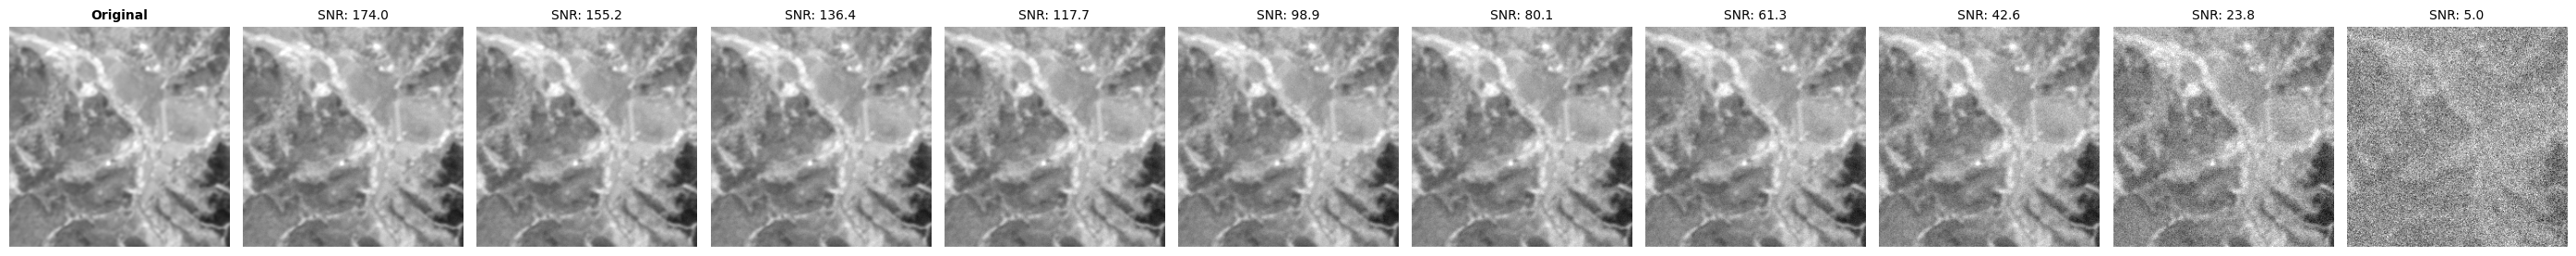

In [9]:
# Apply SNR and MTF to dataset

VMIN = 80
VMAX = 200
tgt_mtf = 0.30
SNR = 174 # Nominal SNR --> for S-2 at B8: 174 | for VENµS: 100. 
SNR_last = 5
SNR_levels = np.linspace(SNR, SNR_last, 10)
tgt_SNR = SNR_levels[9]

full_stack, _ = dm.test_dataset[0] 
img_slice = full_stack[3, :, :] # Band 3

# Create 11 subplots (1 for Original + 10 for SNR levels)
fig, axes = plt.subplots(1, 11, figsize=(28, 5))

# 1. Plot the Original (No Modification)
axes[0].imshow(img_slice, vmin=0.3, vmax=0.9, cmap='gray')
axes[0].set_title("Original", fontsize=10, fontweight='bold')
axes[0].axis('off')

# 2. Plot the perturbed versions
for i in range(10):
    tgt_SNR = SNR_levels[i]
    optics = OpticalSystem('sentinel', tgt_mtf, SNR=tgt_SNR, l_ref=1.0)
    
    processed = optics.apply(img_slice)
    
    im = axes[i+1].imshow(processed, vmin=0.3, vmax=0.9, cmap='gray')
    axes[i+1].axis('off')
    axes[i+1].set_title(f'SNR: {tgt_SNR:.1f}', fontsize=10)

plt.tight_layout()
plt.show()


In [11]:
def perturbed_generator(dataloader, optics):
    """Wraps a dataloader to apply optical perturbations on the fly."""
    for images, masks in dataloader:
        images_np = images.numpy()
        perturbed_images_np = np.zeros_like(images_np)

        # Apply perturbation to all batches and all 7 channels
        for b in range(images_np.shape[0]):
            for c in range(images_np.shape[1]):
                perturbed_images_np[b, c] = optics.apply(images_np[b, c], normalize=True)
        
        yield torch.from_numpy(perturbed_images_np).float(), masks

In [10]:
from evaluation_functions import compute_miou
import warnings

warnings.filterwarnings("ignore")

# 1. Define the perturbation (using your supervisor's SNR and MTF)
# Note: Ensure l_ref=1.0 because your data is normalized (0-1)
optics = OpticalSystem('sentinel', tgt_mtf, SNR=5.0, l_ref=1.0)

print(f"--- Starting Perturbed Evaluation (SNR: {optics.SNR}, MTF: {tgt_mtf}) ---")

# 2. Evaluate ResNet
# We create a new generator for each model to reset the dataset pointer
resnet_perturbed_loader = perturbed_generator(temp_loader, optics)
miou_resnet_perturbed = compute_miou(resnet, resnet_perturbed_loader, num_classes=4, device=device)
print(f"ResNet18 Perturbed mIoU: {miou_resnet_perturbed:.4f}")

# 3. Evaluate PNAS
pynas_perturbed_loader = perturbed_generator(temp_loader, optics)
miou_pynas_perturbed = compute_miou(pynas, pynas_perturbed_loader, num_classes=4, device=device)
print(f"PNAS Perturbed mIoU: {miou_pynas_perturbed:.4f}")

--- Starting Perturbed Evaluation (SNR: 5.0, MTF: 0.3) ---


NameError: name 'perturbed_generator' is not defined

In [14]:
def get_predictions_multi(models, dataloader, device="cpu"):
    """
    models: dict -> {"name": model}
    returns:
        preds_dict: {"name": tensor of predictions}
        labels: ground truth tensor
    """
    preds_dict = {name: [] for name in models}
    labels_all = []

    # Set all models to eval
    for model in models.values():
        model.eval()

    with torch.no_grad():
        for x, y in dataloader:
            x = x.float().to(device)

            if y.ndim == 4:
                y = torch.argmax(y, dim=1)
            y = y.long().to(device)

            labels_all.append(y.cpu())

            for name, model in models.items():
                logits = model(x)
                preds = torch.argmax(logits, dim=1)
                preds_dict[name].append(preds.cpu())

    if len(labels_all) == 0:
        raise ValueError("Dataloader produced no batches!")

    # Concatenate everything
    preds_dict = {
        name: torch.cat(preds_list)
        for name, preds_list in preds_dict.items()
    }

    labels = torch.cat(labels_all)

    return preds_dict, labels


In [35]:
from my_models.my_baseline_models import *

efficientnet = EfficientNetB0UNet(in_channels=7, num_classes=4) 
efficientnet.to(device)  
efficientnet.eval()
state_dict = torch.load("my_models/efficientnetb0_10epochs.pt", map_location=device)
efficientnet.load_state_dict(state_dict)#, strict=False)

mobileone = MobileOneS0UNet(in_channels=7, num_classes=4) 
mobileone.to(device)  
mobileone.eval()
state_dict = torch.load("my_models/mobileone_s0_10epochs.pt", map_location=device)
mobileone.load_state_dict(state_dict)#, strict=False)

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


<All keys matched successfully>

In [37]:
import numpy as np
import pandas as pd
import evaluation_functions
import importlib
importlib.reload(evaluation_functions)

from evaluation_functions import *


import warnings
warnings.filterwarnings("ignore")

# Parameters
VMIN = 80
VMAX = 200
tgt_mtf = 0.30
SNR = 174
SNR_last = 5
SNR_levels = np.linspace(SNR, SNR_last, 10)

# Models
models = {
    "ResNet": resnet,
    "PNAS": pynas,
    "mobilenet": efficientnet,
    "efficientnet": mobileone
}



# Results dictionary (auto-expand per model)
results = {"SNR": []}
for name in models:
    results[f"{name}_mIoU"] = []
    results[f"{name}_consistency"] = []
    results[f"{name}_ICC"] = []

# -----------------------------
# 🔹 Reference (no perturbation)
# -----------------------------
print("\n--- Computing Reference Predictions (No Noise) ---")

ref_preds_dict, ref_labels = get_predictions_multi(models, temp_loader, device)

# -----------------------------
# 🔁 Main loop
# -----------------------------
print(f"\n--- Starting Multi-SNR Evaluation ---")

for snr_val in SNR_levels:
    print(f"\nEvaluating SNR: {snr_val:.2f}")

    optics = OpticalSystem('sentinel', tgt_mtf, SNR=snr_val, l_ref=1.0)

    # ONE generator, ONE pass
    pert_loader = perturbed_generator(temp_loader, optics)

    preds_dict, labels = get_predictions_multi(models, pert_loader, device)

    results["SNR"].append(snr_val)

    for name in models:
        preds = preds_dict[name]
        ref_preds = ref_preds_dict[name]

        # --- Metrics ---
        miou = compute_my_miou_from_preds(preds, labels, num_classes=4)
        consistency = prediction_consistency(ref_preds, preds)
        icc = compute_icc(ref_preds, preds)

        # --- Store ---
        results[f"{name}_mIoU"].append(miou)
        results[f"{name}_consistency"].append(consistency)
        results[f"{name}_ICC"].append(icc)

        print(f"{name} -> mIoU: {miou:.4f}, Cons: {consistency:.4f}, ICC: {icc:.4f}")

print("\n--- Evaluation Complete ---")

df_results = pd.DataFrame(results)
print(df_results)



--- Computing Reference Predictions (No Noise) ---

--- Starting Multi-SNR Evaluation ---

Evaluating SNR: 174.00
ResNet -> mIoU: 0.7994, Cons: 0.9880, ICC: 0.9868
PNAS -> mIoU: 0.8582, Cons: 0.9989, ICC: 0.9979
mobilenet -> mIoU: 0.7674, Cons: 0.8815, ICC: 0.8746
efficientnet -> mIoU: 0.8088, Cons: 0.8944, ICC: 0.8800

Evaluating SNR: 155.22
ResNet -> mIoU: 0.7978, Cons: 0.9858, ICC: 0.9848
PNAS -> mIoU: 0.8582, Cons: 0.9987, ICC: 0.9975
mobilenet -> mIoU: 0.7323, Cons: 0.8548, ICC: 0.8574
efficientnet -> mIoU: 0.7920, Cons: 0.8769, ICC: 0.8720

Evaluating SNR: 136.44
ResNet -> mIoU: 0.7944, Cons: 0.9828, ICC: 0.9819
PNAS -> mIoU: 0.8581, Cons: 0.9985, ICC: 0.9971
mobilenet -> mIoU: 0.6787, Cons: 0.8154, ICC: 0.8354
efficientnet -> mIoU: 0.7588, Cons: 0.8476, ICC: 0.8601

Evaluating SNR: 117.67
ResNet -> mIoU: 0.7905, Cons: 0.9783, ICC: 0.9780
PNAS -> mIoU: 0.8580, Cons: 0.9981, ICC: 0.9964
mobilenet -> mIoU: 0.5980, Cons: 0.7572, ICC: 0.8074
efficientnet -> mIoU: 0.7089, Cons: 0.805